In [1]:
import numpy as np
import torch

from sandbox.jordan8 import *
import matplotlib.pyplot as plt
import re
import os

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

# 1. 

In [3]:
model = JordanNet(encode_dim=32)
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.eval()

C:\Users\micha\AppData\Local\Temp\ipykernel_1680\485095138.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_modif

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [4]:
def test_matrix(A):
    
    # print(np.linalg.eigvals(A))
    d = A.shape[0]
    features = [per_power_features(A)]
    if not np.max(check_doubling_consistency(features[0])[0]) <= 1e-9:
        print("Warning! Doubling consistency check failed:", np.max(check_doubling_consistency(features[0])[0]))
        return None
    features = [x.reshape(d, d*d) for x in features]
    features = torch.tensor(features, dtype=torch.float32)
    logits = model(d, features)
    probs = torch.softmax(logits, dim=-1)
    
    return probs

In [5]:
def run_test(eps):
    T1 = np.zeros((4,4))
    T1[:2,0] = np.random.randn(2)
    T1[:2,2] = np.random.randn(2)

    H1 = np.zeros((4,4))
    H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

    K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

    H2 = np.zeros((8,8))
    H2[:4, :4] = H1
    H2[4:6, 6:8] = np.eye(2)
    H2[6:8, 4:6] = np.eye(2)

    K2 = np.zeros((8,8))
    K2[:4, :4] = K1
    K2[4:6, 6:8] = np.eye(2)
    K2[6:8, 4:6] = np.eye(2)

    T2 = np.zeros((8,8))
    T2[:4,:4] = T1
    T2[:4,5:7] = np.random.randn(4,2)
    T2[5:7,:4] = np.random.randn(2,4)
    T2[5:7,5:7] = np.random.randn(2,2)

    T2_star = H2 @ T2.T @ K2
    TTstar = np.zeros((9,9))
    TTstar[:8,:8] = T2 @ T2_star

    TstarT = np.zeros((9,9))
    TstarT[:8,:8] = T2_star @ T2

    prob1 = test_matrix(TstarT + np.random.randn(9,9) / np.sqrt(9) * eps)
    if prob1 is None:
        cls1 = torch.nan
    else:
        cls1 = torch.argmax(prob1).item()
    prob2 = test_matrix(TTstar + np.random.randn(9, 9) / np.sqrt(9) * eps)
    if prob2 is None:
        cls2 = torch.nan
    else:
        cls2 = torch.argmax(prob2).item()

    H3 = np.zeros((13,13))
    H3[:8,:8] = H2
    H3[8, 8] = 1
    H3[9:11, 11:] = np.eye(2)
    H3[11:, 9:11] = np.eye(2)

    K3 = np.zeros((12,12))
    K3[:8,:8] = K2
    K3[8:10, 10:] = np.eye(2)
    K3[10:, 8:10] = np.eye(2)

    T3 = np.zeros((12, 13))
    T3[:8, :8] = T2
    T3[:8, 9:11] = np.random.randn(8,2)
    T3[8:10, :8] = np.random.randn(2,8)
    T3[8:10, 9:11] = np.random.randn(2,2)

    T3_star = H3 @ T3.T @ K3

    TstarT = T3_star @ T3
    TTstar = T3 @ T3_star
    prob3 = test_matrix(TstarT + np.random.randn(13, 13) / np.sqrt(13) * eps)
    if prob3 is None:
        cls3 = torch.nan
    else:
        cls3 = torch.argmax(prob3).item()
    prob4 = test_matrix(TTstar + np.random.randn(12, 12) / np.sqrt(12) * eps)
    if prob4 is None:
        cls4 = torch.nan
    else:
        cls4 = torch.argmax(prob4).item()

    # plt.plot(prob2.detach().numpy()[0])
    # plt.xticks(ticks=range(12), labels=range(1, 13))
    # plt.show()

    return (cls1, cls2, cls3, cls4) # should return (2, 1, 2, 3)


In [6]:
np.random.seed(1234)
random.seed(1234)
torch.manual_seed(1234)

In [7]:
results = {}
for eps in [0, 1e-8, 1e-6, 1e-3]:
    results[eps] = []
    for _ in range(1000):
        results[eps].append(run_test(eps))

for eps in results.keys():
    results[eps] = np.array(results[eps])

C:\Users\micha\AppData\Local\Temp\ipykernel_1680\435085863.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  features = torch.tensor(features, dtype=torch.float32)


Warning! Doubling consistency check failed: 2.152888668671121e-09
Warning! Doubling consistency check failed: 1.340985781556516e-08
Warning! Doubling consistency check failed: 9.008812019085255e-09
Warning! Doubling consistency check failed: 1.46344616087903e-09
Warning! Doubling consistency check failed: 2.799654593167728e-09
Warning! Doubling consistency check failed: 3.2313107329955616e-09
Warning! Doubling consistency check failed: 1.8445341780166122e-09
Warning! Doubling consistency check failed: 3.462729828451357e-09
Warning! Doubling consistency check failed: 2.295022679651971e-09
Warning! Doubling consistency check failed: 1.1252531096775656e-09
Warning! Doubling consistency check failed: 1.4945912441253036e-09
Warning! Doubling consistency check failed: 4.637434119892929e-09
Warning! Doubling consistency check failed: 1.2388010035221026e-09
Warning! Doubling consistency check failed: 1.7579148745850859e-09
Warning! Doubling consistency check failed: 2.2829575866574983e-09
Warn

In [8]:
def calculate_metrics(results):
    """
    Computes exact accuracy and accuracy @ +-1 for each key in the dict
    and for each column in the matrices, ignoring NaN values.
    """
    true_output = np.array([2, 1, 2, 3])
    metrics_summary = {}

    for key, matrix in results.items():
        # Convert to float numpy array to support NaN values
        matrix = np.array(matrix, dtype=float)
        
        num_columns = matrix.shape[1]
        
        exact_acc_per_col = []
        plus_minus_acc_per_col = []
        
        for col_idx in range(num_columns):
            predictions = matrix[:, col_idx]
            true_val = true_output[col_idx]
            
            # Create a mask of indices that are NOT NaN
            valid_mask = ~np.isnan(predictions)
            
            # Filter predictions to only include non-NaN values
            valid_predictions = predictions[valid_mask]
            
            # Number of valid (non-NaN) samples for this specific column
            num_valid_samples = len(valid_predictions)
            
            # If the entire column is NaN, avoid division by zero
            if num_valid_samples == 0:
                exact_acc_per_col.append(np.nan)
                plus_minus_acc_per_col.append(np.nan)
                continue
            
            # 1. Exact Accuracy (only on valid samples)
            exact_matches = np.sum(valid_predictions == true_val)
            exact_acc = exact_matches / num_valid_samples
            exact_acc_per_col.append(exact_acc)
            
            # 2. Accuracy @ +- 1 (only on valid samples)
            within_one = np.sum(np.abs(valid_predictions - true_val) <= 1)
            plus_minus_acc = within_one / num_valid_samples
            plus_minus_acc_per_col.append(plus_minus_acc)
            
        metrics_summary[key] = {
            "exact_accuracy": exact_acc_per_col,
            "accuracy_plus_minus_1": plus_minus_acc_per_col
        }
        
    return metrics_summary

results_metrics = calculate_metrics(results)

In [9]:
for key, metrics in results_metrics.items():
    print(f"=== Metrics for Key: {key} ===")
    print(f"Exact Accuracy per column:         {metrics['exact_accuracy']}")
    print(f"Accuracy @ ±1 per column:          {metrics['accuracy_plus_minus_1']}\n")

=== Metrics for Key: 0 ===
Exact Accuracy per column:         [np.float64(0.747), np.float64(0.999), np.float64(0.987), np.float64(0.574)]
Accuracy @ ±1 per column:          [np.float64(0.995), np.float64(1.0), np.float64(1.0), np.float64(0.95)]

=== Metrics for Key: 1e-08 ===
Exact Accuracy per column:         [np.float64(0.7407024793388429), np.float64(0.9985358711566618), np.float64(0.996268656716418), np.float64(0.7026209677419355)]
Accuracy @ ±1 per column:          [np.float64(0.996900826446281), np.float64(1.0), np.float64(1.0), np.float64(0.9828629032258065)]

=== Metrics for Key: 1e-06 ===
Exact Accuracy per column:         [np.float64(0.76), np.float64(0.999), np.float64(0.999), np.float64(0.722)]
Accuracy @ ±1 per column:          [np.float64(0.993), np.float64(1.0), np.float64(1.0), np.float64(0.99)]

=== Metrics for Key: 0.001 ===
Exact Accuracy per column:         [np.float64(0.705), np.float64(1.0), np.float64(0.502), np.float64(0.601)]
Accuracy @ ±1 per column:         

# 2.

In [10]:
import pandas as pd

In [11]:
np.random.seed(123)

In [12]:
def naive_classifier(A, eps): 
    k = 1
    d = A.shape[0]
    A_pow = np.eye(d)
    rk_prev = d
    while k < d:
        A_pow = A_pow @ A
        rk = np.linalg.matrix_rank(A_pow, rtol=eps*d if eps > 0 else None)
        # print(k, rk)
        if rk == 0 or rk > rk_prev:
            return k
        else:
            rk_prev = rk
            k += 1
    return k

In [14]:
d = 28 
naive_results = []
for m in range(1, d+1):
    for _ in range(1000):
        if np.random.uniform(0, 1) < 0.1:
            eps = 0.0
        else:
            eps = np.exp(np.random.uniform(np.log(1e-8), np.log(0.1)))

        A, rad, _ = generate_matrix(d, m, 'random', eps)
        if rad > 1:
            rad /= rad
            A /= rad
        pred = naive_classifier(A, eps)
        res = {
            "true_class": m,
            "pred_class": pred,
            "rad": rad,
            "E_norm": eps,
        }
        naive_results.append(res)

naive_results = pd.DataFrame(naive_results)

In [15]:
naive_results.describe()

,true_class,pred_class,rad,E_norm
count,28000.000000,28000.000000,28000.000000,2.800000e+04
mean,14.500000,12.705179,0.361745,5.668431e-03
std,8.077891,8.870936,0.268104,1.582886e-02
min,1.000000,1.000000,0.000000,0.000000e+00
25%,7.750000,4.000000,0.087801,1.517187e-07
50%,14.500000,11.000000,0.380967,1.334740e-05
75%,21.250000,20.000000,0.575973,1.171385e-03
max,28.000000,28.000000,0.944533,9.983364e-02


In [16]:
def load_results_csvs(folder_path):
    """
    Reads all CSV files named results_{d}.csv (d = 1 or 2 digits)
    from the given folder and returns a dict of DataFrames.

    Returns:
        dict[int, pd.DataFrame]: {d: dataframe}
    """
    pattern = re.compile(r"^results_(\d{1,2})\.csv$")
    data = {}

    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        if match:
            d = int(match.group(1))
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            data[d] = df

    return data

nn_results = load_results_csvs("./sandbox/jordan8_results")[28]

In [17]:
naive_results.head()

,true_class,pred_class,rad,E_norm
0,1,2,0.000136,0.000239
1,1,1,0.019987,0.036774
2,1,4,0.000979,0.001699
3,1,1,0.000000,0.000000
4,1,25,0.000057,0.000104


In [18]:
nn_results = nn_results[nn_results["E_norm"]<= 0.1]
naive_results = naive_results[naive_results["E_norm"]<= 0.1]

In [19]:
naive_results.describe()

,true_class,pred_class,rad,E_norm
count,28000.000000,28000.000000,28000.000000,2.800000e+04
mean,14.500000,12.705179,0.361745,5.668431e-03
std,8.077891,8.870936,0.268104,1.582886e-02
min,1.000000,1.000000,0.000000,0.000000e+00
25%,7.750000,4.000000,0.087801,1.517187e-07
50%,14.500000,11.000000,0.380967,1.334740e-05
75%,21.250000,20.000000,0.575973,1.171385e-03
max,28.000000,28.000000,0.944533,9.983364e-02


In [20]:
nn_results.describe()

,true_class,pred_class,kl_loss,E_norm,S_cond,rad
count,280000.000000,280000.000000,280000.000000,280000.000000,280000.000000,280000.000000
mean,13.500000,13.500364,0.060238,0.006711,252.081035,0.389390
std,8.077762,8.077223,0.187169,0.017028,511.723409,0.255200
min,0.000000,0.000000,0.000001,0.000000,12.118155,0.000000
25%,6.750000,7.000000,0.002550,0.000001,56.886024,0.164374
50%,13.500000,14.000000,0.007209,0.000056,99.234824,0.413866
75%,20.250000,21.000000,0.030788,0.002419,211.447916,0.585677
max,27.000000,27.000000,11.095610,0.099997,5598.532682,0.947335


In [21]:

def plot_acc_vs_metric(
    ax,
    df,
    metric="E_norm",
    bins=None,
    k=1,
    s="Model",
    color="tab:blue",
    marker=None,
):
    required = {"true_class", "pred_class", metric}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[["true_class", "pred_class", metric]].dropna().copy()

    # ----------------------------
    # DEFAULT BIN STRUCTURE
    # ----------------------------
    if bins is None:
        bins = np.r_[0, np.logspace(-10, -1, 10)]

    bins = np.asarray(bins)

    # ensure sorted
    bins = np.unique(bins)
    bins.sort()

    # ----------------------------
    # ASSIGN BINS
    # ----------------------------
    data["bin"] = pd.cut(
        data[metric],
        bins=bins,
        include_lowest=True,
        right=True,
    )

    data["acc"] = data["true_class"] == data["pred_class"]
    data["acc_k"] = np.abs(data["true_class"] - data["pred_class"]) <= k

    grouped = data.groupby("bin", observed=True)

    # ----------------------------
    # BIN CENTERS (IMPORTANT FIX)
    # ----------------------------
    left = grouped[metric].min()
    right = grouped[metric].max()

    # geometric mean for log bins, arithmetic for zero bin
    centers = []
    for l, r in zip(left, right):
        if l == 0 or np.isnan(l):
            centers.append(0)  # Directly at 0
        else:
            centers.append(np.sqrt(l * r))

    result = pd.DataFrame({
        "x": centers,
        "acc": grouped["acc"].mean().values,
        "acc_k": grouped["acc_k"].mean().values,
        "count": grouped.size().values,
    })

    # ----------------------------
    # PLOT
    # ----------------------------
    ax.plot(
        result["x"],
        result["acc"],
        linestyle="-",
        marker=marker,
        color=color,
        label=f"{s} (Acc)",
    )

    ax.plot(
        result["x"],
        result["acc_k"],
        linestyle=":",
        marker=marker,
        linewidth=2,
        color=color,
        label=f"{s} (Acc@$\\pm${k})",
    )
    return result

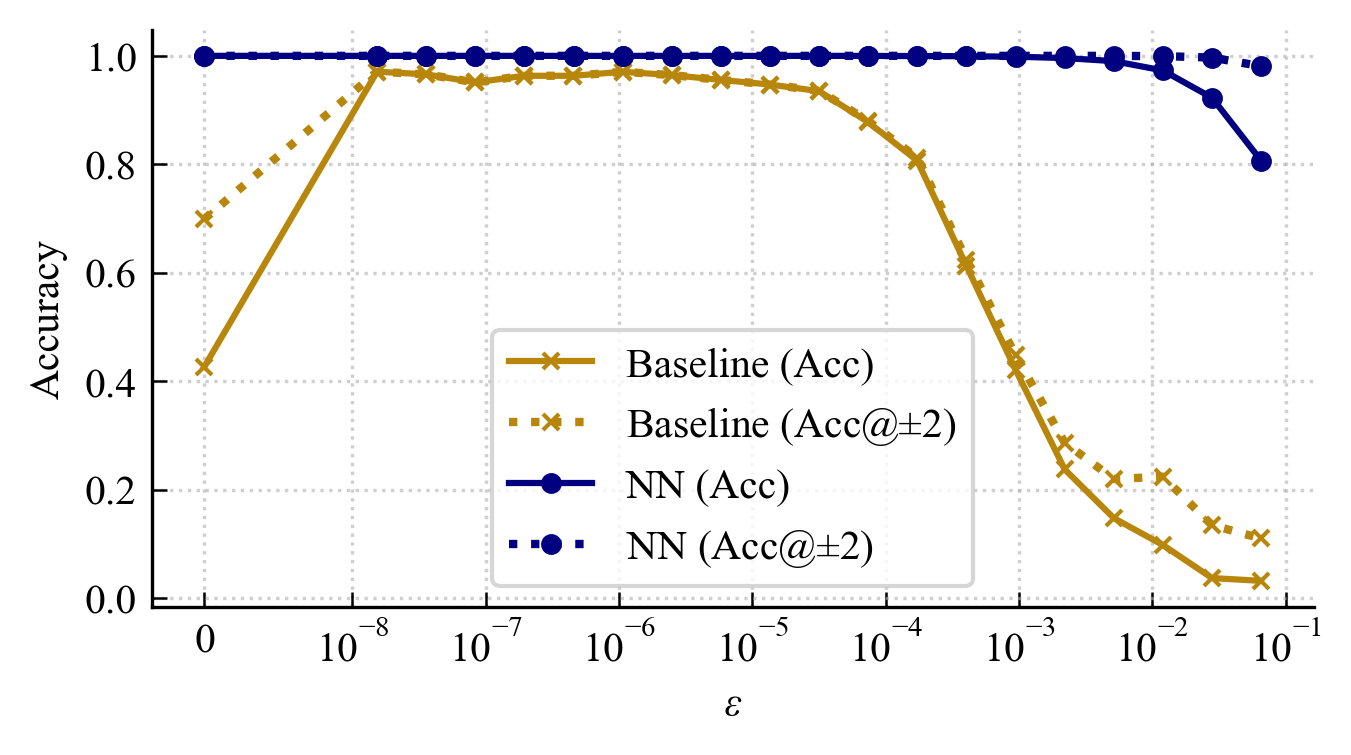

In [23]:
fig, ax = plt.subplots(figsize=(5, 2.5))

bins = np.r_[0, np.logspace(-8, -1, 20)]

plot_acc_vs_metric(
    ax=ax,
    df=naive_results,
    metric="E_norm",
    bins=bins,
    k=2,
    s="Baseline",
    color="darkgoldenrod",
    marker="x"
)

plot_acc_vs_metric(
    ax=ax,
    df=nn_results,
    metric="E_norm",
    bins=bins,
    k=2,
    s="NN",
    color="navy",
    marker="o"
)

ax.set_xscale("symlog", linthresh=1e-8)
ax.legend()
ax.set_xlabel("$\\varepsilon$")
ax.set_ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_naive_a.pdf")
plt.show()

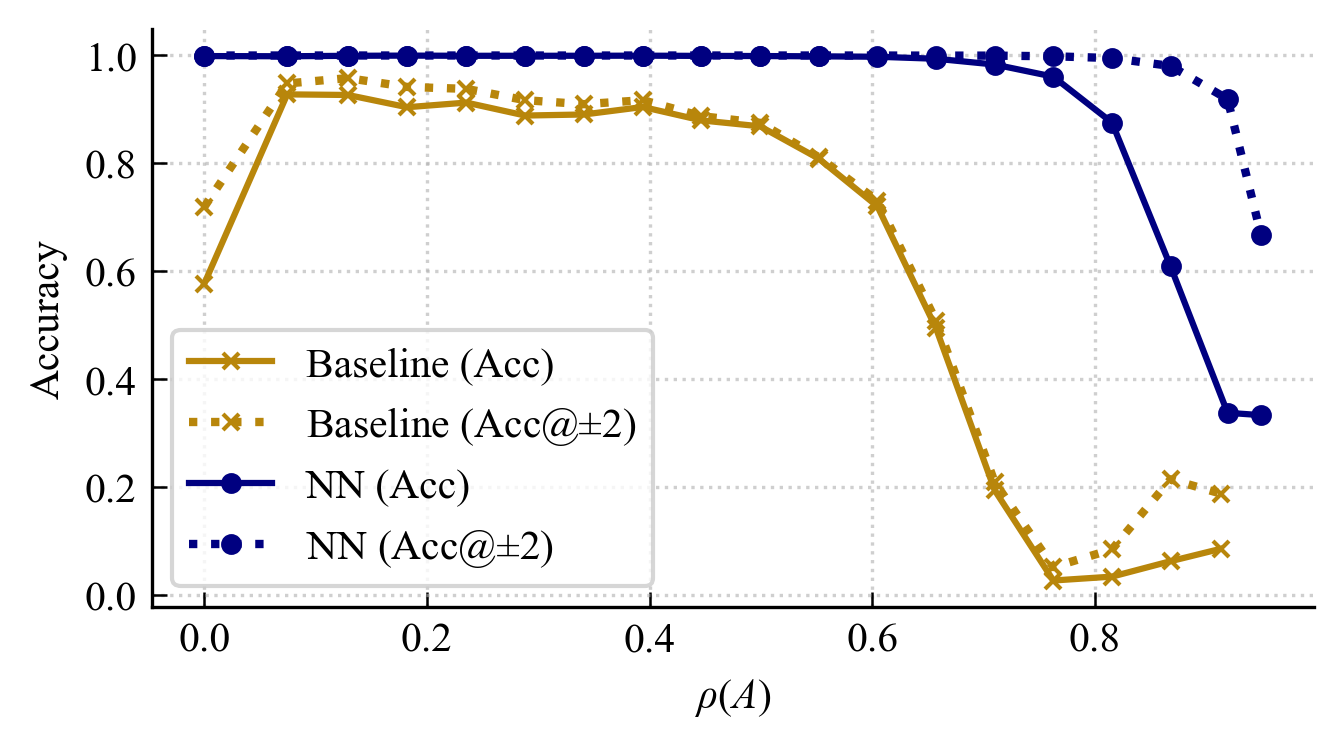

In [ ]:
fig, ax = plt.subplots(figsize=(5, 2.5))

bins = np.linspace(0, 1, 20)

df = plot_acc_vs_metric(
    ax=ax,
    df=naive_results,
    metric="rad",
    bins=bins,
    k=2,
    s="Baseline",
    color="darkgoldenrod",
    marker="x"
)

plot_acc_vs_metric(
    ax=ax,
    df=nn_results,
    metric="rad",
    bins=bins,
    k=2,
    s="NN",
    color="navy",
    marker="o"
)

ax.legend()
ax.set_xlabel("$\\rho(A)$")
ax.set_ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_naive_b.pdf")
plt.show()